# Weak Scaling

This fourth experiment focus on the weak scaling.\
We fix $N/P$, vary $P$. Per-process work stays constant in the local sort phase; per-process communicated volume grows as $N(P-1)/P \to N$. So weak scaling is inherently bad at high $P$ — show this and discuss whether a different sort (e.g. histogram sort or hyperquicksort) would do better and why.

The experiment focus mostly on **MPI** level (since **k** literally is the number of MPI ranks). The number of **OMP threads** are fixed to 4. $N$ varies at each iteration.\
In particular $N/P = 2 \times 10^7$.

* **n_bits** : $64$
* **n_threads** : $4$
* **keys_distribution** : uniform
* **sorting_strategy** : radix
* **merging_strategy** : bin

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_comunication_seconds** and **total_seconds**.

In [11]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [12]:
results = pd.read_csv("../Parallel/results/weak_scaling.csv")

results = results[
    ["n_bits", "n_key", "n_ranks", "n_threads", "time_communication_seconds", "time_total_seconds"]
]
results.head()

results["comm_pct"] = (
    results["time_communication_seconds"] / results["time_total_seconds"]
) * 100

t4_weak = results.loc[results["n_ranks"] == 4, "time_total_seconds"].mean()
results["efficiency"] = (t4_weak / results["time_total_seconds"]) * 100

ranks = results["n_ranks"].unique()
results.head()

,n_bits,n_key,n_ranks,n_threads,time_communication_seconds,time_total_seconds,comm_pct,efficiency
0,64,80000000,4,4,0.284588,1.847196,15.406482,99.592619
1,64,160000000,8,4,0.420208,2.293183,18.324234,80.223468
2,64,320000000,16,4,0.622116,2.692368,23.106655,68.329126
3,64,640000000,32,4,1.290926,3.897005,33.126102,47.207308
4,64,80000000,4,4,0.286718,1.831426,15.655431,100.450181


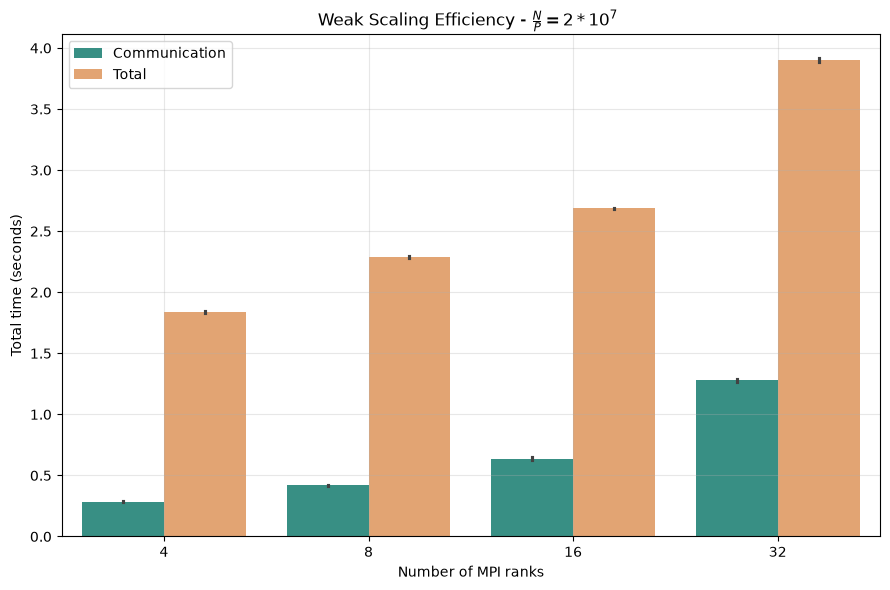

In [13]:
plot_data = results.melt(
    id_vars=["n_bits", "n_key", "n_ranks", "n_threads"],
    value_vars=[
        "time_communication_seconds",
        "time_total_seconds"
    ],
    var_name="time_type",
    value_name="time_seconds"
)

plot_data["time_type"] = plot_data["time_type"].map({
    "time_communication_seconds": "Communication",
    "time_total_seconds": "Total"
})

custom_palette = {
    "Communication" : "#2A9D8F",
    "Total" : "#F4A261"
}


baseline = (
    results.loc[results["n_ranks"].idxmin(), "time_total_seconds"]
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=plot_data,
    x="n_ranks",
    y="time_seconds",
    hue="time_type",
    palette=custom_palette
)

plt.xlabel("Number of MPI ranks")
plt.ylabel("Total time (seconds)")
plt.title(r"Weak Scaling Efficiency - $\frac{N}{P} = 2*10^7$ ")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

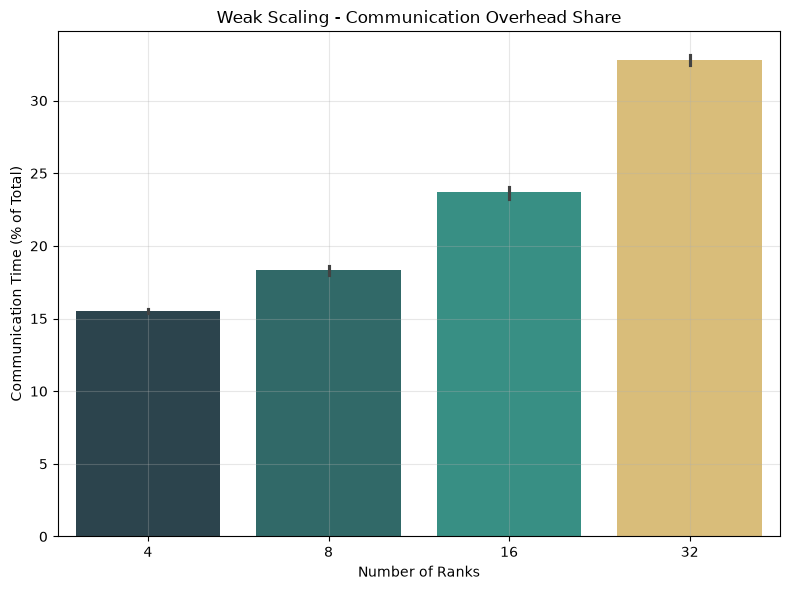

In [14]:
custom_palette_ranks = {
    4: "#264653",
    8: "#287271",
    16: "#2a9d8f",
    32: "#e9c46a",
    64: "#f4a261",
    128: "#ee8959",
    256: "#e76f51",
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="comm_pct",
    hue="n_ranks",
    palette=custom_palette_ranks,
    legend=False
)

plt.xlabel("Number of Ranks")
plt.ylabel("Communication Time (% of Total)")
plt.title("Weak Scaling - Communication Overhead Share")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

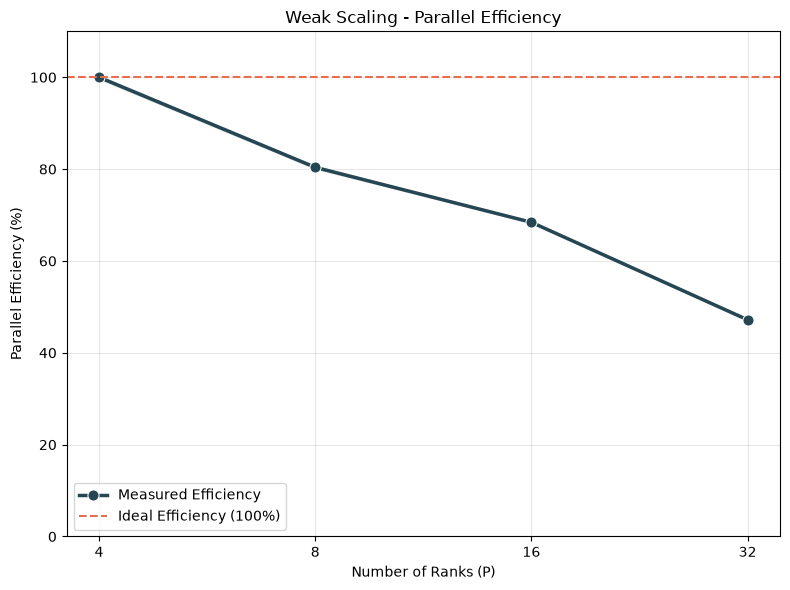

In [15]:
plt.figure(figsize=(8, 6))

# Plot measured efficiency curve using Seaborn
ax = sns.lineplot(
    data=results,
    x="n_ranks",
    y="efficiency",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#264653",
    label="Measured Efficiency",
)

# Plot reference 100% ideal efficiency line
plt.axhline(
    y=100,
    linestyle="--",
    color="#E76F51",
    linewidth=1.5,
    label="Ideal Efficiency (100%)",
)

# Set log scale for x-axis to evenly space power-of-2 rank counts
plt.xscale("log", base=2)
ranks = sorted(results["n_ranks"].unique())
plt.xticks(ranks, ranks)

plt.xlabel("Number of Ranks (P)")
plt.ylabel("Parallel Efficiency (%)")
plt.title("Weak Scaling - Parallel Efficiency")
plt.ylim(0, 110)
plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()